In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('weather_prediction_dataset.csv')
dates = pd.date_range('2000-01-01', '2010-12-31', freq='D')
if len(df) != len(dates):
    dates = dates[:len(df)]
df['date'] = dates
df = df[['date', 'BASEL_temp_max']].rename(columns={'BASEL_temp_max': 'max_temp'})
df = df.set_index('date')
df.head()

,max_temp
date,
2000-01-01,3.9
2000-01-02,4.8
2000-01-03,4.8
2000-01-04,7.5
2000-01-05,8.6


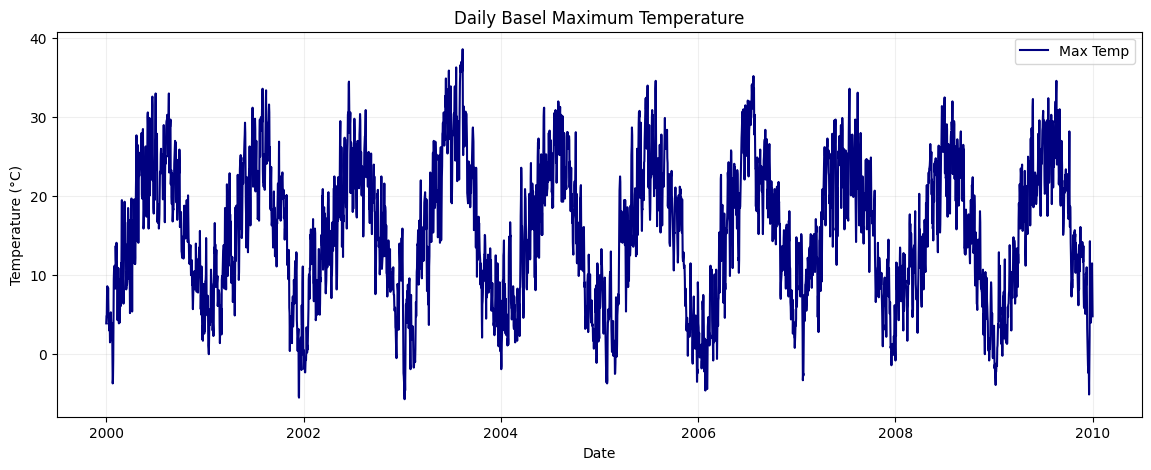

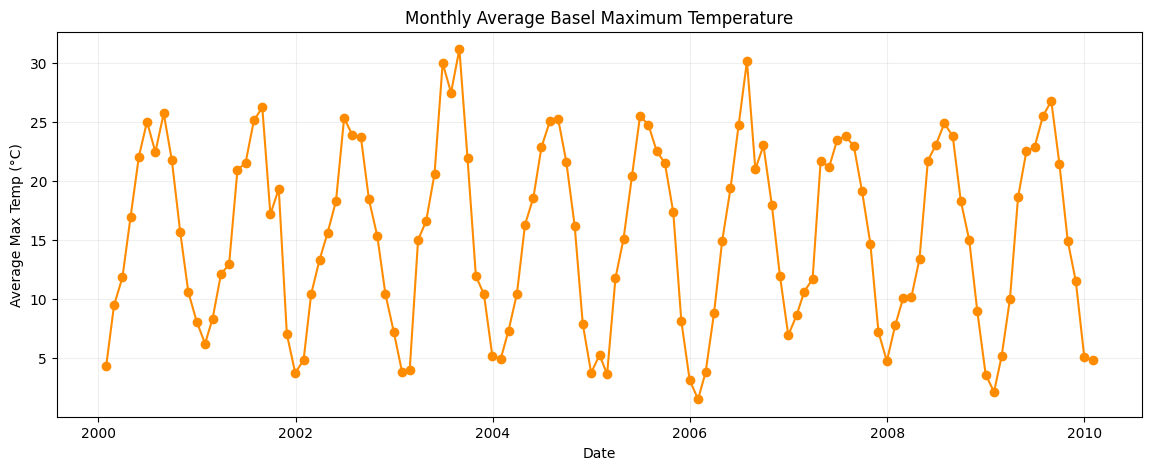

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['max_temp'], color='navy', label='Max Temp')
plt.title('Daily Basel Maximum Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()
monthly = df['max_temp'].resample('ME').mean()
plt.figure(figsize=(14, 5))
plt.plot(monthly.index, monthly.values, color='darkorange', marker='o')
plt.title('Monthly Average Basel Maximum Temperature')
plt.xlabel('Date')
plt.ylabel('Average Max Temp (°C)')
plt.grid(True, alpha=0.2)
plt.show()

In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(df[['max_temp']].values)
def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)
window_size = 30
X, y = create_sequences(scaled_values, window_size=window_size)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]
X_train.shape, X_val.shape, X_test.shape

((2536, 30, 1), (543, 30, 1), (545, 30, 1))

In [10]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(30),
    Dropout(0.2),
    Dense(10, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,441 (79.85 KB)

 Trainable params: 20,441 (79.85 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/100
80/80 - 11s - 143ms/step - loss: 0.0322 - mean_absolute_error: 0.1323 - val_loss: 0.0111 - val_mean_absolute_error: 0.0857 - learning_rate: 0.0010
Epoch 2/100
80/80 - 3s - 40ms/step - loss: 0.0142 - mean_absolute_error: 0.0958 - val_loss: 0.0121 - val_mean_absolute_error: 0.0895 - learning_rate: 0.0010
Epoch 3/100
80/80 - 3s - 41ms/step - loss: 0.0131 - mean_absolute_error: 0.0923 - val_loss: 0.0107 - val_mean_absolute_error: 0.0842 - learning_rate: 0.0010
Epoch 4/100
80/80 - 3s - 39ms/step - loss: 0.0127 - mean_absolute_error: 0.0915 - val_loss: 0.0109 - val_mean_absolute_error: 0.0851 - learning_rate: 0.0010
Epoch 5/100
80/80 - 3s - 42ms/step - loss: 0.0112 - mean_absolute_error: 0.0861 - val_loss: 0.0093 - val_mean_absolute_error: 0.0783 - learning_rate: 0.0010
Epoch 6/100
80/80 - 3s - 41ms/step - loss: 0.0112 - mean_absolute_error: 0.0855 - val_loss: 0.0093 - val_mean_absolute_error: 0.0785 - learning_rate: 0.0010
Epoch 7/100
80/80 - 4s - 44ms/step - loss: 0.0102 - mean

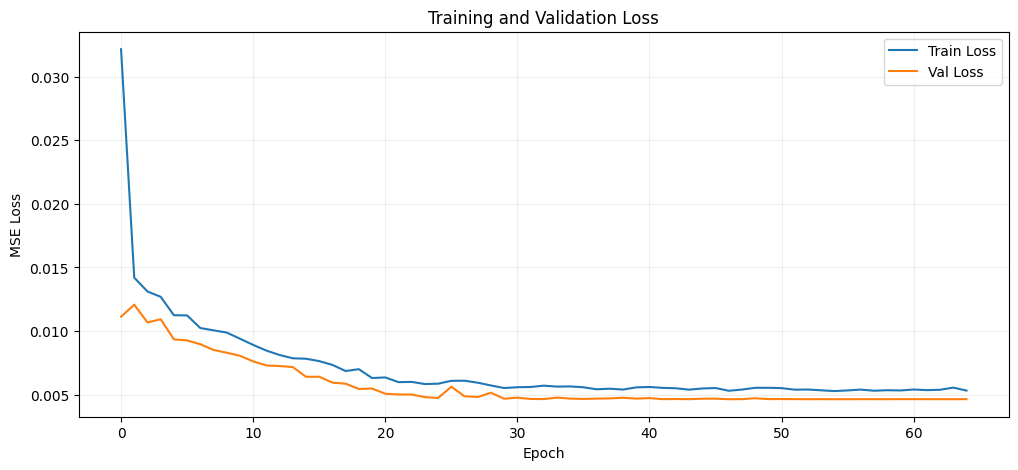

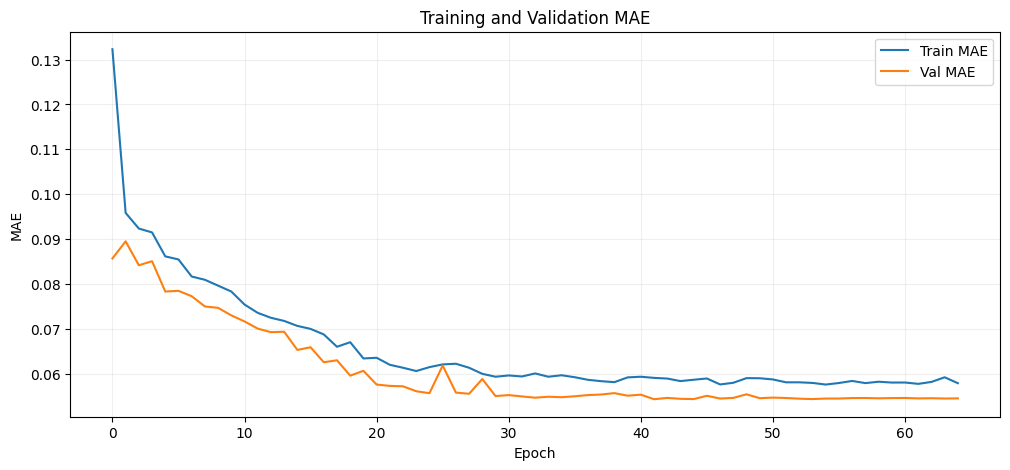

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Val MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('training_mae_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled).ravel()
y_actual = scaler.inverse_transform(y_test).ravel()
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)
binary_accuracy = np.mean(np.abs(y_pred - y_actual) <= 2.0)
print(f'MAE: {mae:.3f} °C')
print(f'RMSE: {rmse:.3f} °C')
print(f'R2: {r2:.3f}')
print(f'Accuracy within ±2°C: {binary_accuracy * 100:.2f}%')

MAE: 2.383 °C
RMSE: 2.983 °C
R2: 0.887
Accuracy within ±2°C: 48.62%


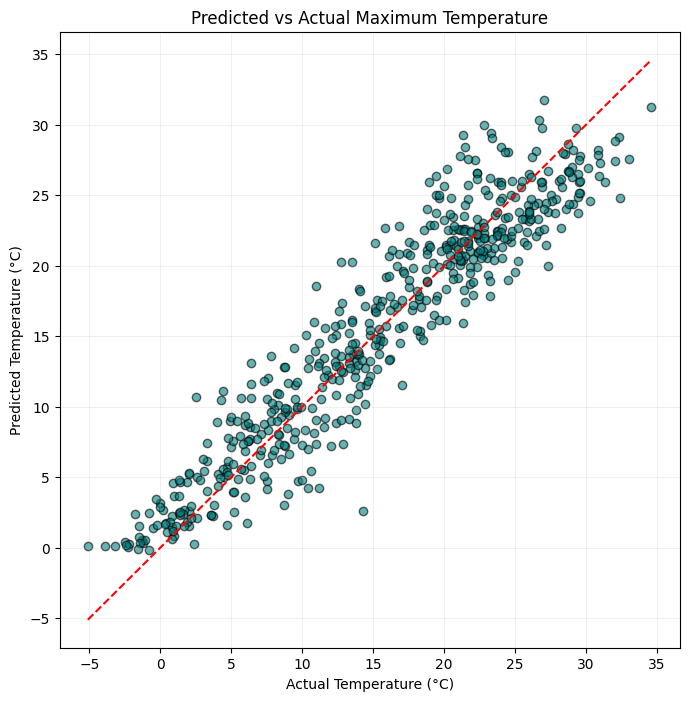

In [14]:
plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_pred, alpha=0.6, color='teal', edgecolors='k')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')
plt.title('Predicted vs Actual Maximum Temperature')
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.grid(True, alpha=0.2)
plt.savefig('pred_vs_actual_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

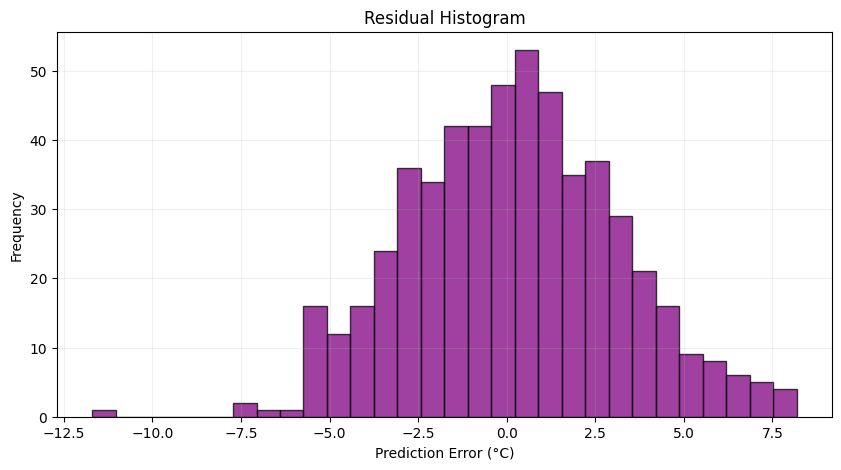

In [15]:
residuals = y_pred - y_actual
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30, color='purple', edgecolor='black', alpha=0.75)
plt.title('Residual Histogram')
plt.xlabel('Prediction Error (°C)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.2)
plt.savefig('residuals_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

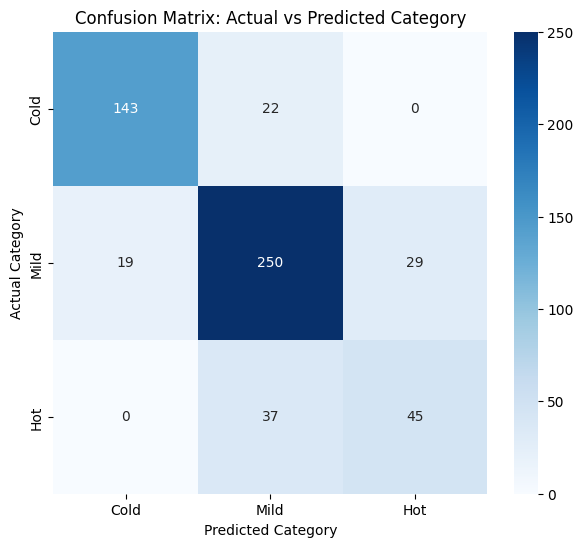

In [16]:
def temp_category(values):
    categories = []
    for v in values:
        if v < 10:
            categories.append('Cold')
        elif v <= 25:
            categories.append('Mild')
        else:
            categories.append('Hot')
    return categories
actual_cat = temp_category(y_actual)
pred_cat = temp_category(y_pred)
cm = confusion_matrix(actual_cat, pred_cat, labels=['Cold', 'Mild', 'Hot'])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cold', 'Mild', 'Hot'], yticklabels=['Cold', 'Mild', 'Hot'])
plt.title('Confusion Matrix: Actual vs Predicted Category')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.savefig('confusion_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
model.save('weather_lstm_model.h5')
joblib.dump(scaler, 'scaler.pkl')
print('Saved model to weather_lstm_model.h5 and scaler to scaler.pkl')

Saved model to weather_lstm_model.h5 and scaler to scaler.pkl


In [18]:
persistence_scaled = X_test[:, -1, 0].reshape(-1, 1)
persistence_actual = scaler.inverse_transform(persistence_scaled).ravel()
baseline_mae = mean_absolute_error(y_actual, persistence_actual)
improvement_pct = (baseline_mae - mae) / baseline_mae * 100 if baseline_mae != 0 else 0.0
print(f'Baseline persistence MAE: {baseline_mae:.3f} °C')
print(f'Model improvement over baseline: {improvement_pct:.2f}%')

Baseline persistence MAE: 2.428 °C
Model improvement over baseline: 1.86%


In [19]:
# Export a model architecture diagram for the report rubric
from tensorflow.keras.utils import plot_model

try:
    plot_model(
        model,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        dpi=96
    )
    print('Saved model architecture diagram to model_architecture.png')
except Exception as e:
    print('Could not save model architecture diagram. Check that graphviz and pydot are installed.')
    print('Error:', e)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Saved model architecture diagram to model_architecture.png


In [20]:
# Build and print a formatted training parameter table
import tensorflow as tf

train_size = len(X_train)
val_size = len(X_val)
test_size = len(X_test)

learning_rate = getattr(model.optimizer, 'learning_rate', None)
if hasattr(learning_rate, 'numpy'):
    learning_rate = float(learning_rate.numpy())
optimizer_name = getattr(model.optimizer, 'name', model.optimizer.__class__.__name__)
loss_name = model.loss if isinstance(model.loss, str) else (
    model.loss.__name__ if callable(model.loss) else str(model.loss)
)
hardware = 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'

params = {
    'Parameter': [
        'Training set size',
        'Validation set size',
        'Test set size',
        'Window size',
        'Batch size',
        'Epochs',
        'Learning rate',
        'Optimizer',
        'Loss function',
        'Hardware used'
    ],
    'Value': [
        train_size,
        val_size,
        test_size,
        window_size,
        32,
        100,
        learning_rate,
        optimizer_name,
        loss_name,
        hardware
    ]
}

params_df = pd.DataFrame(params)
print('Training parameters:')
print(params_df.to_string(index=False))

Training parameters:
          Parameter              Value
  Training set size               2536
Validation set size                543
      Test set size                545
        Window size                 30
         Batch size                 32
             Epochs                100
      Learning rate           0.000004
          Optimizer               adam
      Loss function mean_squared_error
      Hardware used                CPU


In [21]:
# Display a small sample of actual vs predicted values for demonstration
sample_df = pd.DataFrame({
    'Actual max temp': y_actual[:10],
    'Predicted max temp': y_pred[:10],
    'Error': (y_pred[:10] - y_actual[:10])
})

print('Actual vs. Predicted values (first 10 rows):')
print(sample_df.round(3).to_string(index=False))

Actual vs. Predicted values (first 10 rows):
 Actual max temp  Predicted max temp  Error
            22.3           26.587999  4.288
            22.4           22.747999  0.348
            20.0           23.226999  3.227
            24.1           21.290001 -2.810
            29.1           24.379000 -4.721
            28.5           27.888000 -0.612
            20.2           26.886999  6.687
            17.4           20.917000  3.517
            20.6           19.469000 -1.131
            24.7           21.680000 -3.020
